In [8]:
import pandas as pd

df = pd.read_csv('student.csv')
print(df.head())

print("DataSet shape")
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

print("DataSet info")
print(df.info())

print("summary statistics")
print(df.describe(include='all'))

print("Missing values")
print(df.isnull().sum())




   StudyHours  Attendance  PastScore Internet  SleepHours Passed
0           2          60         40      Yes           5     No
1           5          80         60       No           6    Yes
2           8          90         75      Yes           8    Yes
3           3          70         50      Yes           5     No
4           7          85         70       No           7    Yes
DataSet shape
Rows: 20
Columns: 6
DataSet info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   StudyHours  20 non-null     int64 
 1   Attendance  20 non-null     int64 
 2   PastScore   20 non-null     int64 
 3   Internet    20 non-null     object
 4   SleepHours  20 non-null     int64 
 5   Passed      20 non-null     object
dtypes: int64(4), object(2)
memory usage: 1.1+ KB
None
summary statistics
        StudyHours  Attendance  PastScore Internet  SleepHours Pass

In [9]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('student.csv')

print("missing values in each column:")
print(df.isnull().sum())

le = LabelEncoder()


df['Internet'] = le.fit_transform(df['Internet'])
df['Passed'] = le.fit_transform(df['Passed'])

print("after encoding:")
print(df.head())

print('Data-types after cleaning:')
print(df.dtypes)

missing values in each column:
StudyHours    0
Attendance    0
PastScore     0
Internet      0
SleepHours    0
Passed        0
dtype: int64
after encoding:
   StudyHours  Attendance  PastScore  Internet  SleepHours  Passed
0           2          60         40         1           5       0
1           5          80         60         0           6       1
2           8          90         75         1           8       1
3           3          70         50         1           5       0
4           7          85         70         0           7       1
Data-types after cleaning:
StudyHours    int64
Attendance    int64
PastScore     int64
Internet      int64
SleepHours    int64
Passed        int64
dtype: object


Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.67      0.80         3

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4



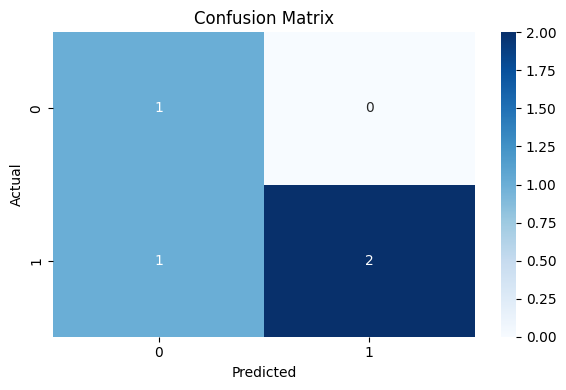

-------predict your results-------
Based on the input, the predicted result is: FAILED


In [10]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

features = ['StudyHours', 'Attendance', 'Internet', 'PastScore', 'SleepHours']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

x = df_scaled[features].values
y = df_scaled['Passed'].values
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("-------predict your results-------")
try:
    study_hours = float(input("Enter study hours: "))
    attendance = float(input("Enter attendance percentage: "))
    internet = input("Do you have internet access? (yes/no): ").strip().lower()
    past_score = float(input("Enter past score: "))
    sleep_hours = float(input("Enter sleep hours: "))

    user_input_df = pd.DataFrame({
        'StudyHours': [study_hours],
        'Attendance': [attendance],
        'Internet': [1 if internet == 'yes' else 0],
        'PastScore': [past_score],
        'SleepHours': [sleep_hours]
    })

    user_input_scaled = scaler.transform(user_input_df[features])
    prediction = model.predict(user_input_scaled)[0]
    result = "PASSED" if prediction == 1 else "FAILED"
    print(f"Based on the input, the predicted result is: {result}")
except ValueError:
    print("An error occured" , e)